<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/4_Flavour_oscillation_(1)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact
!pip install oscillations


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 14.97 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/NuOscProbExact/NuOscProbExact


In [47]:
#Minimal “three‑flavour”

import oscillations
import matplotlib.pyplot as plt
from scipy.linalg import expm
import numpy as np

plt.rcParams.update({
    'font.size'         : 16,   # controls default text size
    'axes.titlesize'    : 20,   # controls title size
    'axes.labelsize'    : 18,   # controls x & y label size
    'xtick.labelsize'   : 14,   # controls tick label size
    'ytick.labelsize'   : 14,   # controls tick label size
    'legend.fontsize'   : 14,   # controls legend font size
})


# initialize
osc = oscillations.Oscillations()

# set experimental parameters
osc.setTheta23(90.0 * oscillations.units.degrees)
osc.setE(1.0 * oscillations.units.GeV)
osc.setL(3000.0 * oscillations.units.km)

# compute a transition probability
p = osc.p(oscillations.nu_mu, oscillations.nu_e)
print("P(νμ → νe) =", p)

# show the parameters
print("\nParameters used:\n", osc)

P(νμ → νe) = 0.014666546483500147

Parameters used:
 theta_12 = 33.90 degrees
theta_23 = 90.00 degrees
theta_13 = 9.10 degrees
(Delta m^2)_21 = 75.00 meV^2
(Delta m^2)_32 = 2320.00 meV^2
(Delta m^2)_31 = 2395.00 meV^2
L   = 3000.0 km 
E   = 1.0 GeV
L/E = 3000.00 km/GeV


In [48]:
# Matter‐potential helper (3×3 Hamiltonian)


# Fermi constant in eV·cm^3/g
G_F = 8.9e-5

def add_matter_effects(hamiltonian, density, electron_fraction=1.0):
    """
    Add MSW potential to the (0,0) entry of a 3×3 Hamiltonian.
    density in g/cm^3, electron_fraction usually ≃0.5 in Earth crust.
    """
    V = np.sqrt(2) * G_F * density * electron_fraction
    hamiltonian[0, 0] += V
    return hamiltonian


H0 = np.zeros((3, 3))
H_mat = add_matter_effects(H0, density=2.6, electron_fraction=0.5)
print("3×3 Hamiltonian with matter:\n", H_mat)

3×3 Hamiltonian with matter:
 [[0.00016362 0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]


In [49]:
def build_3plus1_hamiltonian(theta23, delta_m31, delta_m41, theta34, energy):
    """
    Returns a 4×4 vacuum Hamiltonian for the 3+1 model.
    Angles in degrees, delta_m in eV², energy in GeV.
    """
    # to radians
    t23 = np.radians(theta23)
    t34 = np.radians(theta34)

    H = np.zeros((4, 4))
    # active sector
    H[1, 1] = delta_m31 / (2 * energy)
    H[2, 2] = (delta_m31 / (2 * energy)) * np.sin(2 * t23)
    # sterile sector
    H[3, 3] = delta_m41 / (2 * energy)
    H[2, 3] = (delta_m41 / (2 * energy)) * np.sin(2 * t34)
    H[3, 2] = H[2, 3]
    return H


delta_m41_sq = 1.78      # eV^2
theta_14   = np.arcsin(np.sqrt(0.089)) / 2
theta_24   = np.arcsin(np.sqrt(0.13 )) / 2
theta_34   = 0.0         # assume negligible
L          = 810         # baseline in km

# Example
H4 = build_3plus1_hamiltonian(
    theta23=45.0,
    delta_m31=2.4e-3,
    delta_m41=1.0,
    theta34=30.0,
    energy=1.0
)
print("3+1 Hamiltonian:\n", H4)

3+1 Hamiltonian:
 [[0.        0.        0.        0.       ]
 [0.        0.0012    0.        0.       ]
 [0.        0.        0.0012    0.4330127]
 [0.        0.        0.4330127 0.5      ]]


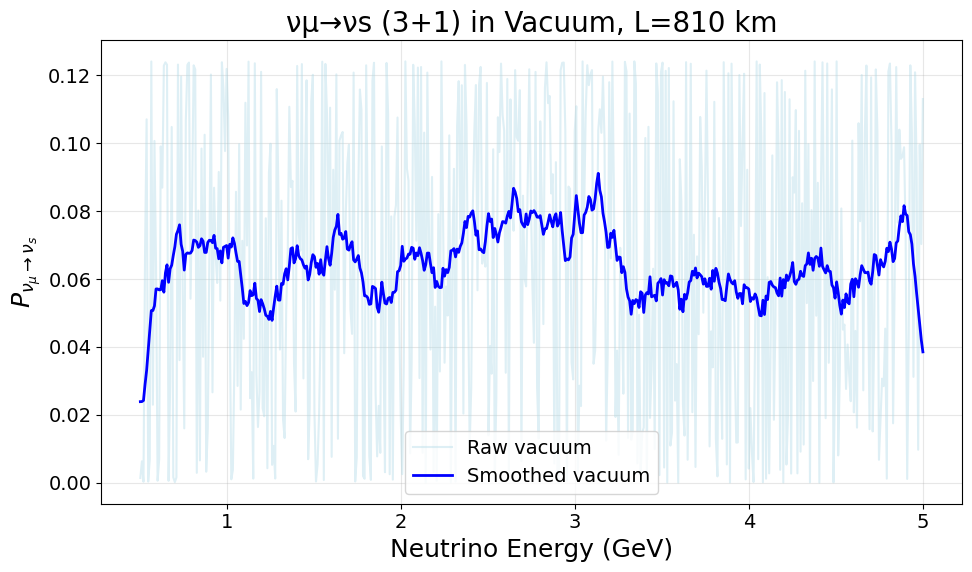

In [50]:
# reuse G_F, etc. from before
L_km_to_eV = 5.07e9  # km → eV⁻¹

# 4×4 toy mixing matrix (approximate)
def U_matrix(theta_14, theta_24, theta_34):
    c14, s14 = np.cos(theta_14), np.sin(theta_14)
    c24, s24 = np.cos(theta_24), np.sin(theta_24)
    c34, s34 = np.cos(theta_34), np.sin(theta_34)
    return np.array([
        [  c14,          0,          0,   s14],
        [-s14*s24,      c24,         0,  c14*s24],
        [-s14*c24*s34,-s24*s34,     c34, c14*c24*s34],
        [ s14*c24*c34, s24*c34,     s34,-c14*c24*c34]
    ])

def compute_transition_probability(E, L, dm41, th14, th24, th34, matter=False):
    """
    Returns P(νμ→νs) in the 4×4 3+1 model.
    E [GeV], L [km], dm41 [eV2], angles [rad].
    """
    # build U & mass matrix exactly as you had...
    U = U_matrix(th14, th24, th34)
    Delta = np.diag([0, 0, 0, dm41]) / (2 * E)
    Hvac = U @ Delta @ U.T

    if matter:
        # 4×4, only [0,0] gets MSW term
        dens = 2.8  # example
        Ye = 0.5
        V = np.sqrt(2) * G_F * dens * Ye
        H = Hvac.copy()
        H[0,0] += V
    else:
        H = Hvac

    # propagate
    Le = L * L_km_to_eV
    U_t = expm(-1j * H * Le)

    nu_mu = np.array([0,1,0,0])
    nu_s  = np.array([0,0,0,1])
    amp = nu_s.conj() @ (U_t @ nu_mu)
    return np.abs(amp)**2

# Energy grid
energies = np.linspace(0.5, 5.0, 500)
pv = np.array([compute_transition_probability(E, 810, 1.78, theta_14, theta_24, theta_34, False)
               for E in energies])
# Smooth with a 21‑point boxcar
pv_s = np.convolve(pv, np.ones(21)/21, mode='same')

plt.figure(figsize=(10,6))
plt.plot(energies, pv,   color='lightblue', alpha=0.4, label='Raw vacuum')
plt.plot(energies, pv_s, color='blue',       lw=2, label='Smoothed vacuum')

plt.xlabel("Neutrino Energy (GeV)")    # will be size 18
plt.ylabel(r"$P_{\nu_\mu\to\nu_s}$")   # will be size 18
plt.title("νμ→νs (3+1) in Vacuum, L=810 km")  # will be size 20

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

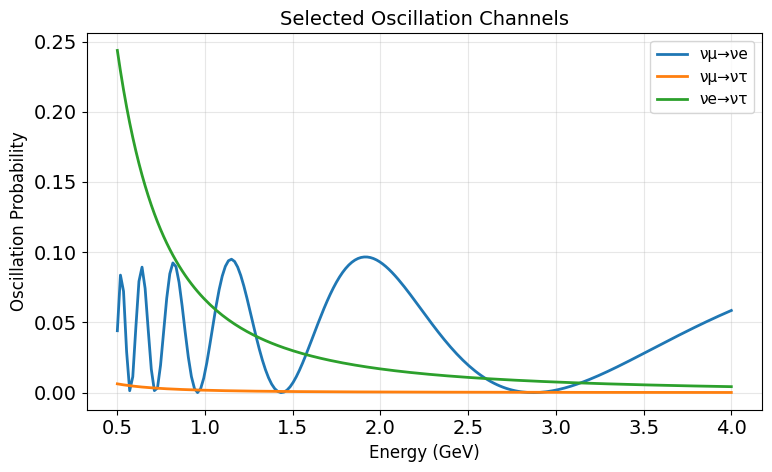

In [51]:
# ———— 2) Oscillation Channels ————
import oscillations

def plot_neutral_interactions(osc, channels, energies=None):
    """
    osc       : oscillations.Oscillations() instance
    channels  : dict mapping label -> (initial, final) flavor enums
    energies  : array-like of neutrino energies in GeV; defaults to a fine grid
    """
    if energies is None:
        energies = np.linspace(0.5, 4.0, 200)   # ← dense sampling!

    Es = np.array(energies)
    plt.figure(figsize=(8, 5))

    for label, (nu_i, nu_f) in channels.items():
        probs = []
        for E in Es:
            osc.setE(E * oscillations.units.GeV)
            probs.append(osc.p(nu_i, nu_f))

        plt.plot(Es, probs, '-', lw=2, label=label)

    plt.xlabel("Energy (GeV)",             fontsize=12)
    plt.ylabel("Oscillation Probability", fontsize=12)
    plt.title("Selected Oscillation Channels", fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# now call
interactions = {
    "νμ→νe": (oscillations.nu_mu,  oscillations.nu_e),
    "νμ→ντ": (oscillations.nu_mu,  oscillations.nu_tau),
    "νe→ντ": (oscillations.nu_e,   oscillations.nu_tau),
}

plot_neutral_interactions(osc, interactions)

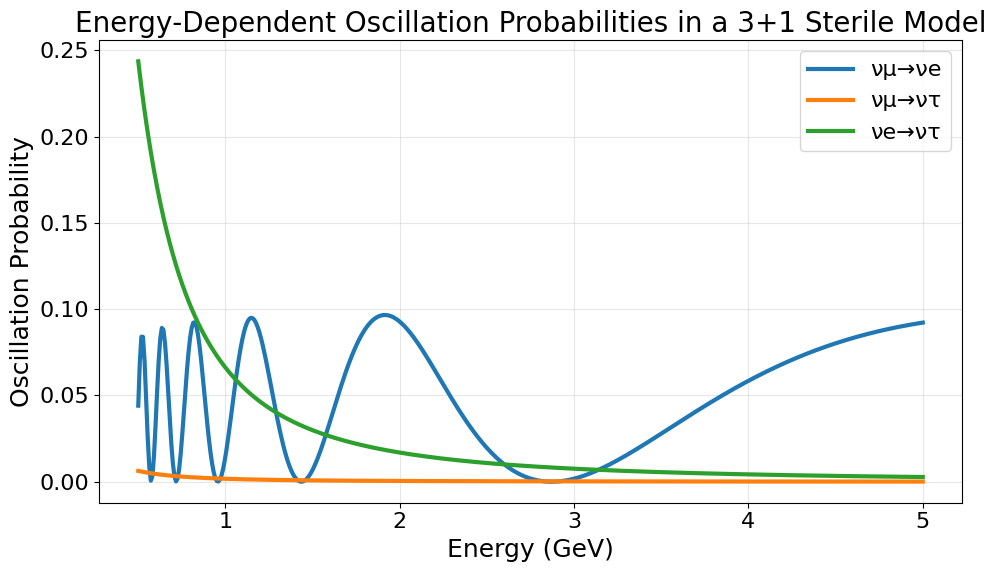

In [52]:
def plot_selected_channels(osc, channels, energies):
    Es = np.array(energies)

    plt.figure(figsize=(10, 6))
    for label, (nu_i, nu_f) in channels.items():
        probs = []
        for E in Es:
            osc.setE(E * oscillations.units.GeV)
            probs.append(osc.p(nu_i, nu_f))
        # solid line only, no markers:
        plt.plot(Es, probs, '-', lw=3, label=label)

    # Enlarged labels/title:
    plt.xlabel("Energy (GeV)",              fontsize=18)
    plt.ylabel("Oscillation Probability",    fontsize=18)
    plt.title("Energy‐Dependent Oscillation Probabilities in a 3+1 Sterile Model", fontsize=20)

    # Enlarged tick labels:
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(fontsize=16, loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


interactions = {
    "νμ→νe": (oscillations.nu_mu,  oscillations.nu_e),
    "νμ→ντ": (oscillations.nu_mu,  oscillations.nu_tau),
    "νe→ντ": (oscillations.nu_e,   oscillations.nu_tau),
}

# Use 500 points for a smooth curve:
energies = np.linspace(0.5, 5.0, 500)
plot_selected_channels(osc, interactions, energies)

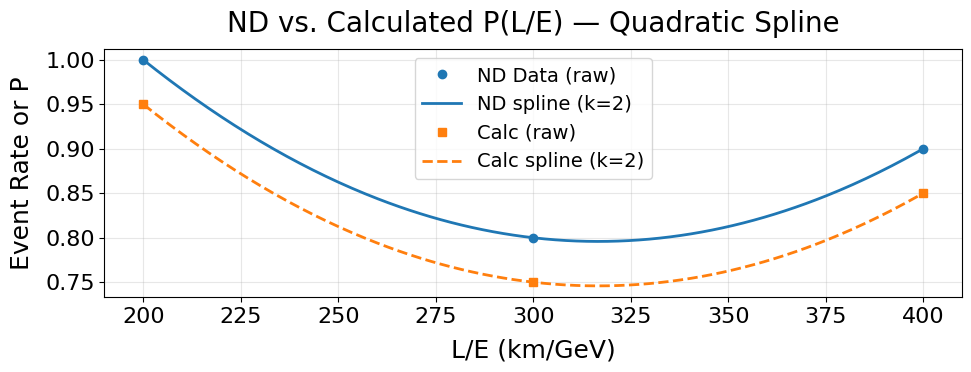

In [53]:
nd_data   = {'x': np.array([200,300,400]), 'y': np.array([1.0,0.8,0.9])}
calc_data = {'x': np.array([200,300,400]), 'y': np.array([0.95,0.75,0.85])}

# fine grid
x_fine = np.linspace(nd_data['x'].min(), nd_data['x'].max(), 300)

# 1) fit a quadratic spline (k=2) through the ND points
spline_nd = UnivariateSpline(nd_data['x'], nd_data['y'], k=2, s=0)
y_nd_smooth = spline_nd(x_fine)

# 2) same for the calc curve
spline_calc = UnivariateSpline(calc_data['x'], calc_data['y'], k=2, s=0)
y_calc_smooth = spline_calc(x_fine)

plt.figure(figsize=(10,4))

plt.plot(nd_data['x'], nd_data['y'],       'o',  color='C0', label='ND Data (raw)')
plt.plot(x_fine,    y_nd_smooth,           '-',  color='C0', lw=2,    label='ND spline (k=2)')
plt.plot(calc_data['x'], calc_data['y'],   's',  color='C1', label='Calc (raw)')
plt.plot(x_fine,       y_calc_smooth,       '--', color='C1', lw=2,    label='Calc spline (k=2)')

plt.xlabel("L/E (km/GeV)",   fontsize=18, labelpad=8)
plt.ylabel("Event Rate or P", fontsize=18, labelpad=8)
plt.title("ND vs. Calculated P(L/E) — Quadratic Spline", fontsize=20, pad=12)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(fontsize=14, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()